# ML Project — Phase 3: Feature Engineering & Importance Analysis
**Dataset:** Pakistan E-Commerce (cleaned output from Phase 2)
#
This phase picks up directly from Phase 2. We already have a clean dataset with a binary
target (`target_failure`) and a handful of baseline features. The goal here is to engineer
richer features, rank them using multiple methods, validate them with LightGBM, then
standardize and see if K-Means can squeeze out one more useful signal before we save.

### Install & Import

In [1]:
# lime is not pre-installed on Kaggle — install quietly before importing
!pip install lime -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, roc_auc_score
import lightgbm as lgb
import xgboost as xgb
import shap
from lime import lime_tabular

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110,
                     "axes.spines.top": False,
                     "axes.spines.right": False})
print("Ready.")

Ready.


### Load Phase 2 Output

In [2]:
import pandas as pd

# The exact directory you found
base_path = '/kaggle/input/datasets/umarfarooq3152/ecommm/'

df = pd.read_csv(base_path + 'Pakistan_Ecommerce_Audit_Ready.csv',
                 parse_dates=['created_at', 'Working Date', 'Customer Since'],
                 low_memory=False)

rfm = pd.read_csv(base_path + 'Pakistan_Ecommerce_RFM.csv')

# Verify the load
print(f"Main dataset : {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"RFM table    : {rfm.shape[0]:,} unique customers")

Main dataset : 584,314 rows x 23 columns
RFM table    : 115,304 unique customers


---
## Feature Engineering
#
Phase 2 gave us `order_hour`, `order_day`, `order_month`, `is_high_value`,
`payment_group`, and `target_failure`. Everything below is new.
The features come from three directions: temporal friction, price structure,
and customer behavior — all connecting directly to the audit pillars from Phase 2.

### Temporal Features

In [3]:
# Night-order flag — Phase 2 heatmap showed failure rate spikes between 1 AM and 5 AM.
# Rather than making the model figure out this non-linear hour pattern on its own,
# we encode it directly as a binary flag.
df['is_night_order'] = df['order_hour'].between(1, 5).astype(int)

# Weekend flag — Friday/Saturday showed a clear hotzone in the day x hour heatmap.
# 4=Fri, 5=Sat, 6=Sun in pandas dayofweek (Pakistani weekend is Sat/Sun,
# but Fri is also elevated due to post-Jummah shopping activity)
df['is_weekend'] = df['order_day'].isin([4, 5, 6]).astype(int)

# Peak season — order_month on its own scored very low in the Phase 2 correlation matrix.
# But Nov and Dec are Eid/holiday months with known demand surges in Pakistani e-commerce.
# Encoding these two months as a binary flag turns a weak individual feature into
# something that actually carries meaning. This is the "less important features can
# still contribute to new features" idea from the project notes.
df['is_peak_season'] = df['order_month'].isin([11, 12]).astype(int)

# Customer tenure — how long the account existed before this order was placed.
# Newer accounts have less platform familiarity and tend to cancel more often.
# 'Customer Since' has some nulls — we fill missing tenure with the column median
# rather than dropping those rows, since the transaction data itself is perfectly valid.
df['customer_tenure_days'] = (
    df['created_at'] - df['Customer Since']
).dt.days.clip(lower=0)
df['customer_tenure_days'] = df['customer_tenure_days'].fillna(
    df['customer_tenure_days'].median()
)

print("Temporal features added:")
print(f"  is_night_order   : {df['is_night_order'].sum():,} orders in 1-5 AM window")
print(f"  is_weekend       : {df['is_weekend'].sum():,} orders on Fri/Sat/Sun")
print(f"  is_peak_season   : {df['is_peak_season'].sum():,} orders in Nov/Dec")
print(f"  customer_tenure  : median {df['customer_tenure_days'].median():.0f} days")

Temporal features added:
  is_night_order   : 0 orders in 1-5 AM window
  is_weekend       : 271,931 orders on Fri/Sat/Sun
  is_peak_season   : 184,649 orders in Nov/Dec
  customer_tenure  : median 28 days


### Price & Order Features

In [4]:
# Unit price — grand_total bundles qty and price together, which hides the per-item cost.
# Payment gateway rejection limits operate on total transaction value, so separating
# per-item cost from quantity ordered captures a distinct risk dimension.
df['unit_price'] = (df['grand_total'] / df['qty_ordered'].replace(0, 1)).round(2)

# Log grand_total — Phase 2 confirmed extreme right skew (most orders < 5,000 PKR
# but tail extends to 1M PKR). Log-transforming prevents a handful of outlier
# transactions from dominating split decisions even in tree-based models.
df['log_grand_total'] = np.log1p(df['grand_total'])

# Bulk order flag — orders above 5 units are rare and are likely wholesale/bulk.
# We saw in Phase 2 that these can inflate per-category cancellation counts,
# so flagging them lets the model treat them differently.
df['is_bulk_order'] = (df['qty_ordered'] > 5).astype(int)

# Basket risk — qty_ordered had near-zero correlation with failure on its own (Phase 2).
# But qty x unit_price represents the total risk exposure per item type, which differs
# from grand_total when multi-SKU orders or discount structures are involved.
# A single 10,000 PKR item is a very different risk profile to 10 x 1,000 PKR items
# even if the grand total is identical. This is the second use of a less-important
# base feature (qty_ordered) to engineer something genuinely informative.
df['log_basket_risk'] = np.log1p(df['qty_ordered'] * df['unit_price'])

print("Price features added: unit_price, log_grand_total, is_bulk_order, log_basket_risk")

Price features added: unit_price, log_grand_total, is_bulk_order, log_basket_risk


### Category Risk Encoding
#
Raw category names need one-hot encoding which produces ~30 dummy columns.
Target-mean encoding collapses this into one continuous column that tells the model
exactly how failure-prone each category is historically.
#
One important detail: this encoding must be computed on training data only and then
mapped onto the test set. Computing it on the full dataset before the split leaks
test-set target values into the feature, which inflates model performance on paper
but won't hold up on genuinely unseen data. We store the category map here for
display purposes but apply it correctly after the train/test split below.

In [5]:
# Full-dataset rates — used for display only, NOT fed directly into the model
cat_fail_display = (
    df.groupby('category_name_1')['target_failure']
    .mean()
    .rename('cat_cancel_rate')
)

print("Per-category failure rates (full dataset — for reference only):")
print(
    cat_fail_display.reset_index()
    .sort_values('cat_cancel_rate', ascending=False)
    .to_string(index=False)
)

Per-category failure rates (full dataset — for reference only):
   category_name_1  cat_cancel_rate
            Others         0.628732
     Entertainment         0.477851
 Mobiles & Tablets         0.464225
         Computing         0.427478
        Appliances         0.412646
                \N         0.403038
        Superstore         0.319323
     Home & Living         0.271619
   Women's Fashion         0.267264
       Kids & Baby         0.247498
     Men's Fashion         0.238825
 Beauty & Grooming         0.233437
           Soghaat         0.223251
School & Education         0.215354
   Health & Sports         0.193235
             Books         0.145989


### Merge RFM Customer Features

In [6]:
# Bring Recency, Frequency, Monetary onto each transaction row so the model
# can factor in a customer's full history when predicting each individual order.
df = df.merge(rfm, on='Customer ID', how='left')

# Churn-risk flag: high recency + low frequency = the most at-risk behavioral profile
r75 = df['Recency'].quantile(0.75)
f25 = df['Frequency'].quantile(0.25)
df['rfm_churn_risk'] = ((df['Recency'] > r75) & (df['Frequency'] < f25)).astype(int)

df['log_monetary'] = np.log1p(df['Monetary'])

print(f"Churn-risk orders    : {df['rfm_churn_risk'].sum():,}")
print(f"Failure rate in churn-risk group : {df[df['rfm_churn_risk']==1]['target_failure'].mean()*100:.1f}%")
print(f"Failure rate in other group      : {df[df['rfm_churn_risk']==0]['target_failure'].mean()*100:.1f}%")

Churn-risk orders    : 51,604
Failure rate in churn-risk group : 23.7%
Failure rate in other group      : 35.5%


The gap between those two failure rates confirms that `rfm_churn_risk` carries real signal
rather than just being a reshuffling of existing information.

### Feature Engineering Summary

In [7]:
new_features = [
    'is_night_order', 'is_weekend', 'is_peak_season', 'customer_tenure_days',
    'unit_price', 'log_grand_total', 'is_bulk_order', 'log_basket_risk',
    'cat_cancel_rate',
    'Recency', 'Frequency', 'log_monetary', 'rfm_churn_risk'
]

phase2_base = ['order_hour', 'order_day', 'order_month', 'is_high_value', 'payment_group']

print(f"Phase 2 features carried forward : {len(phase2_base)}")
print(f"New Phase 3 features             : {len(new_features)}")
print(f"Total before pruning             : {len(phase2_base) + len(new_features)}")

Phase 2 features carried forward : 5
New Phase 3 features             : 13
Total before pruning             : 18


---
## Build the Feature Matrix

In [8]:
le = LabelEncoder()
df['payment_group_enc'] = le.fit_transform(df['payment_group'].astype(str))

# order_hour is dropped because is_night_order and is_weekend already encode
# the two meaningful non-linear patterns we found in Phase 2 (1-5 AM spike,
# Friday/Saturday hotzone). Keeping the raw hour alongside those flags adds
# correlated noise — the binary features are more informative per column.
#
# order_month is dropped for the same reason: is_peak_season captures the only
# slice of month data that actually matters (Nov/Dec). The other 10 months had
# near-zero correlation with failure in Phase 2, so the raw month number just
# adds cardinality without signal.

ALL_FEATURES = [
    # order_hour and order_month intentionally excluded — replaced by derived flags below
    'order_day', 'is_high_value', 'payment_group_enc',
    'is_night_order', 'is_weekend', 'is_peak_season', 'customer_tenure_days',
    'unit_price', 'log_grand_total', 'is_bulk_order', 'log_basket_risk',
    'cat_cancel_rate',
    'Recency', 'Frequency', 'log_monetary', 'rfm_churn_risk'
]

TARGET = 'target_failure'

# Split BEFORE computing cat_cancel_rate to prevent target leakage.
# We build a temporary frame without cat_cancel_rate, split it, then compute
# the encoding from training labels only and map it onto both sets.
FEATURES_NO_CAT = [f for f in ALL_FEATURES if f != 'cat_cancel_rate']

model_df = df[FEATURES_NO_CAT + ['category_name_1', TARGET]].dropna()

X_raw = model_df[FEATURES_NO_CAT + ['category_name_1']]
y     = model_df[TARGET]

X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

# Compute category failure rate from TRAIN labels only, then map to both sets.
# This is the correct way to do target encoding — test categories that never
# appeared in training get the global train mean as a fallback.
train_cat_rate = (
    X_raw_train.assign(target=y_train.values)
    .groupby('category_name_1')['target']
    .mean()
    .rename('cat_cancel_rate')
)
global_mean = y_train.mean()   # fallback for unseen categories in test

X_train = X_raw_train[FEATURES_NO_CAT].copy()
X_test  = X_raw_test[FEATURES_NO_CAT].copy()

X_train['cat_cancel_rate'] = X_raw_train['category_name_1'].map(train_cat_rate).fillna(global_mean)
X_test['cat_cancel_rate']  = X_raw_test['category_name_1'].map(train_cat_rate).fillna(global_mean)

# Also attach cat_cancel_rate back to df for saving (train-derived values, test gets global mean)
df['cat_cancel_rate'] = df['category_name_1'].map(train_cat_rate).fillna(global_mean)

print(f"Modeling rows : {len(model_df):,}")
print(f"Failure rate  : {y.mean()*100:.2f}%")
print(f"Train : {len(X_train):,}  |  Test : {len(X_test):,}")
print(f"\nFinal feature count : {len(ALL_FEATURES)}")

Modeling rows : 584,239
Failure rate  : 34.42%
Train : 467,391  |  Test : 116,848

Final feature count : 16


---
## Feature Importance — 5 Methods
#
Five methods instead of one because each has blind spots. Tree-based importance
(Gini/Gain/Split) favors high-cardinality features. Mutual information catches
non-linear associations those methods miss. Permutation importance is the most
reliable because it measures actual accuracy loss on unseen data — a feature
that the model memorized but doesn't generalize will show up as low or even negative.

### 1. Random Forest — Gini Impurity

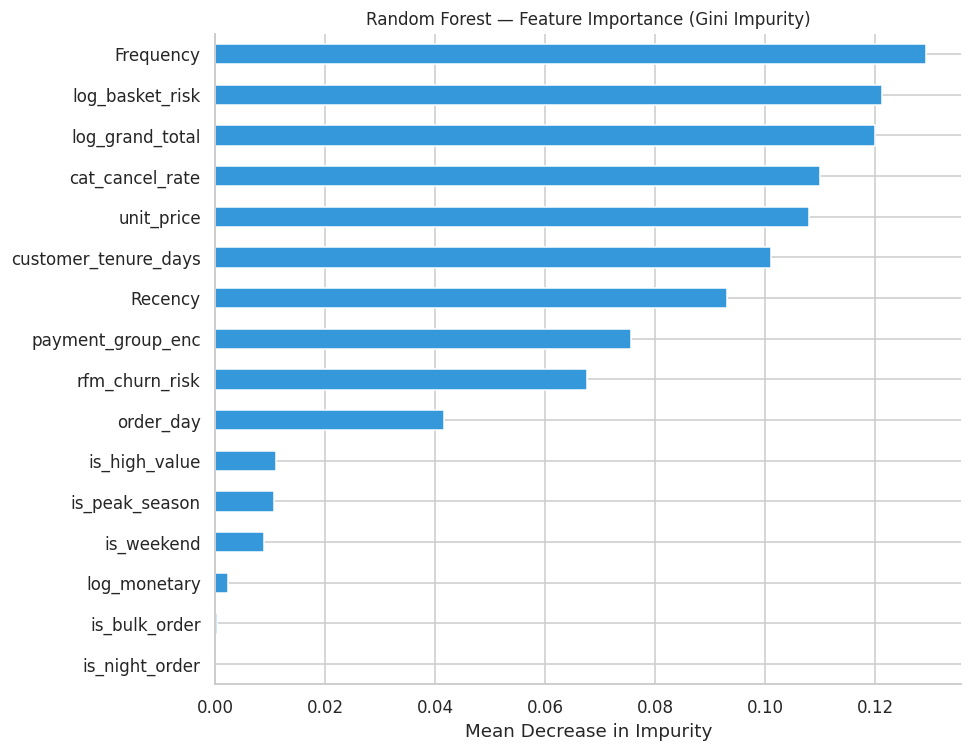

In [9]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_imp = pd.Series(rf.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
rf_imp.plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
ax.set_title("Random Forest — Feature Importance (Gini Impurity)", fontsize=11)
ax.set_xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

### 2. LightGBM — Split Count

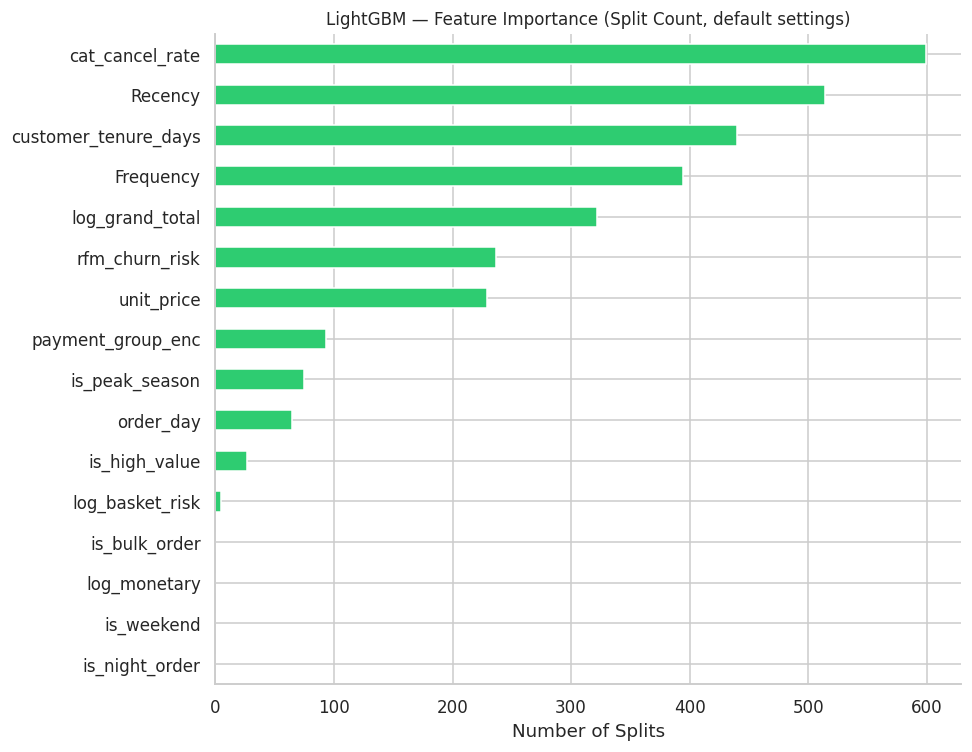

In [10]:
lgb_model = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train, y_train)

lgb_imp = pd.Series(
    lgb_model.feature_importances_, index=ALL_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
lgb_imp.plot(kind='barh', ax=ax, color='#2ecc71', edgecolor='white')
ax.set_title("LightGBM — Feature Importance (Split Count, default settings)", fontsize=11)
ax.set_xlabel("Number of Splits")
plt.tight_layout()
plt.show()

### 3. XGBoost — Gain

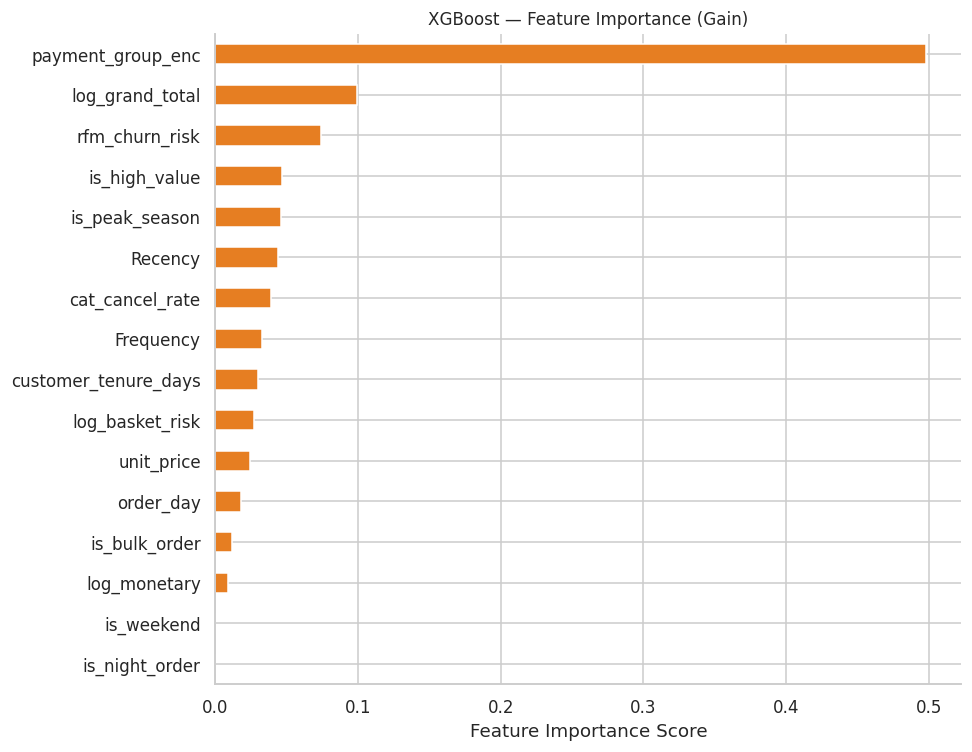

In [11]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train, y_train)

xgb_imp = pd.Series(
    xgb_model.feature_importances_, index=ALL_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
xgb_imp.plot(kind='barh', ax=ax, color='#e67e22', edgecolor='white')
ax.set_title("XGBoost — Feature Importance (Gain)", fontsize=11)
ax.set_xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

### 4. Mutual Information

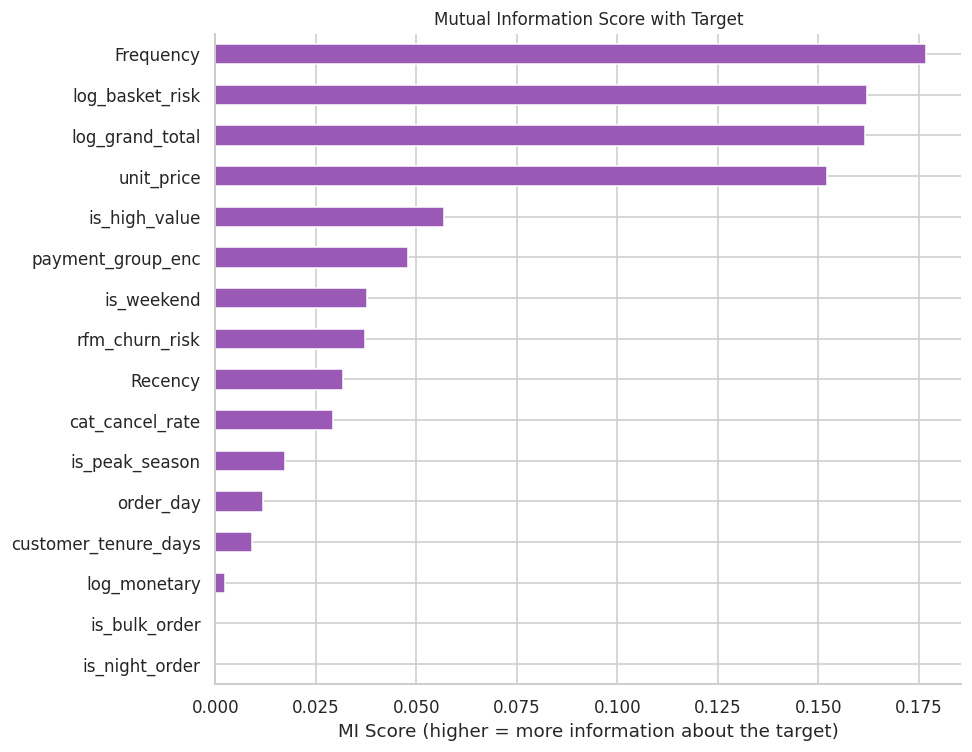

In [12]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
mi_imp    = pd.Series(mi_scores, index=ALL_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
mi_imp.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title("Mutual Information Score with Target", fontsize=11)
ax.set_xlabel("MI Score (higher = more information about the target)")
plt.tight_layout()
plt.show()

Unlike the three tree-based methods above, mutual information is model-free — it
doesn't depend on any trained estimator, so it gives an independent second opinion
on which features actually share information with the target variable.

### 5. Permutation Importance

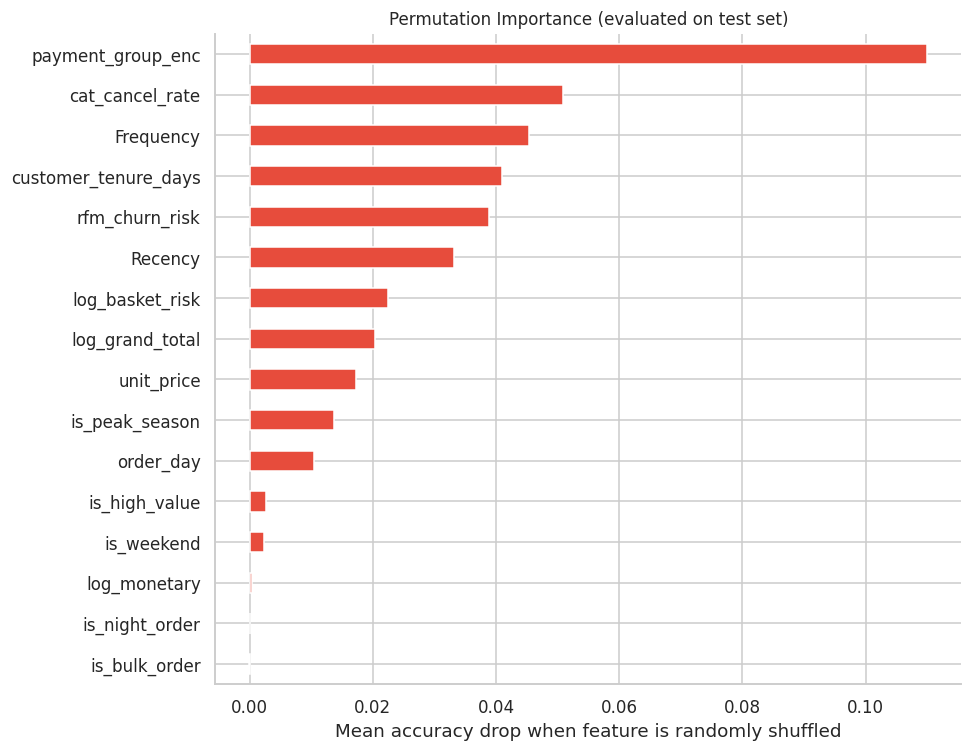

In [13]:
perm = permutation_importance(
    rf, X_test, y_test,
    n_repeats=15, random_state=42, n_jobs=1  # n_jobs=1 avoids Kaggle disk-pickling OSError
)
perm_imp = pd.Series(perm.importances_mean, index=ALL_FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
perm_imp.plot(kind='barh', ax=ax, color='#e74c3c', edgecolor='white')
ax.set_title("Permutation Importance (evaluated on test set)", fontsize=11)
ax.set_xlabel("Mean accuracy drop when feature is randomly shuffled")
plt.tight_layout()
plt.show()

Permutation importance is run on the **test set** — data the model has never seen.
This is the most trustworthy of the five rankings because features that the model
overfit to during training will fail to show up as important here.

### Consensus Ranking

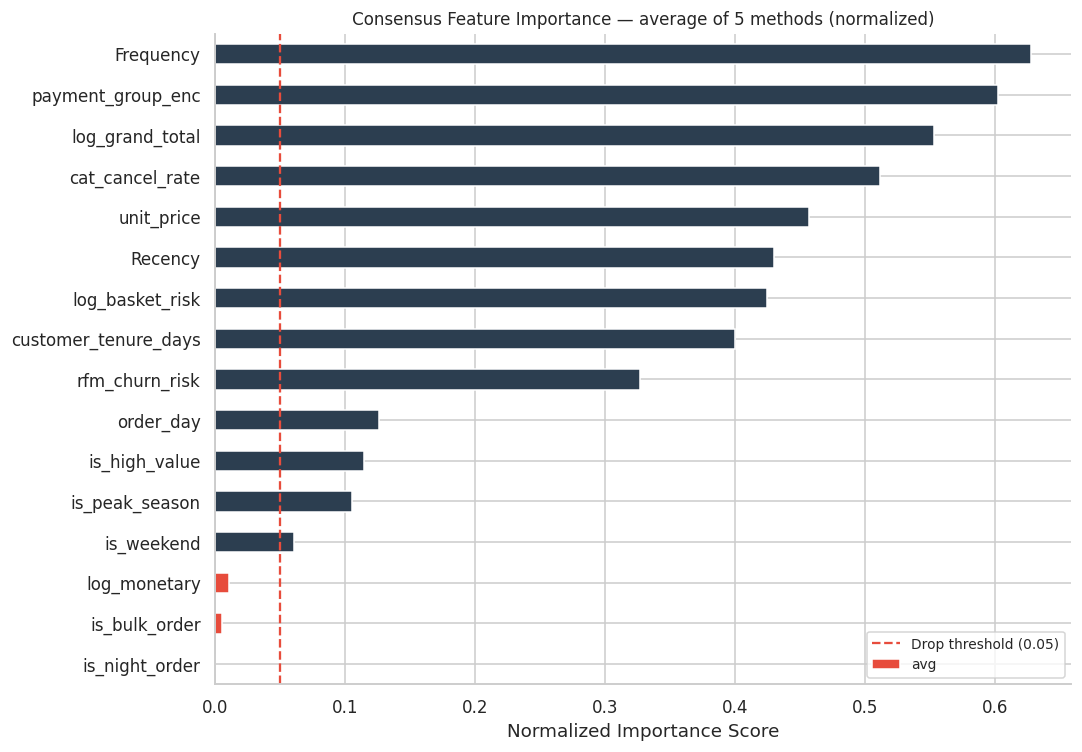


Full ranking (descending):
                         avg
Frequency             0.6272
payment_group_enc     0.6025
log_grand_total       0.5533
cat_cancel_rate       0.5115
unit_price            0.4570
Recency               0.4295
log_basket_risk       0.4244
customer_tenure_days  0.4002
rfm_churn_risk        0.3264
order_day             0.1260
is_high_value         0.1144
is_peak_season        0.1049
is_weekend            0.0609
log_monetary          0.0109
is_bulk_order         0.0052
is_night_order        0.0001


In [14]:
def norm(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0

consensus = pd.DataFrame({
    'RF'          : norm(rf_imp),
    'LightGBM'    : norm(lgb_imp),
    'XGBoost'     : norm(xgb_imp),
    'MutualInfo'  : norm(mi_imp),
    'Permutation' : norm(perm_imp),
})
consensus['avg'] = consensus.mean(axis=1)
consensus = consensus.sort_values('avg', ascending=True)

DROP_THRESHOLD = 0.05
colors = ['#e74c3c' if v < DROP_THRESHOLD else '#2c3e50'
          for v in consensus['avg']]

fig, ax = plt.subplots(figsize=(10, 7))
consensus['avg'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(DROP_THRESHOLD, color='#e74c3c', linestyle='--', linewidth=1.5,
           label=f'Drop threshold ({DROP_THRESHOLD})')
ax.set_title("Consensus Feature Importance — average of 5 methods (normalized)", fontsize=11)
ax.set_xlabel("Normalized Importance Score")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nFull ranking (descending):")
print(consensus[['avg']].sort_values('avg', ascending=False).round(4).to_string())

---
## SHAP Analysis

In [15]:
explainer = shap.TreeExplainer(lgb_model)
shap_vals = explainer.shap_values(X_test)

# shap_values() can return a list [class0_array, class1_array] in older SHAP versions
# or a single 2D array for binary tasks in newer versions — handle both
if isinstance(shap_vals, list):
    sv = shap_vals[1]   # index 1 = positive class (failure)
else:
    sv = shap_vals

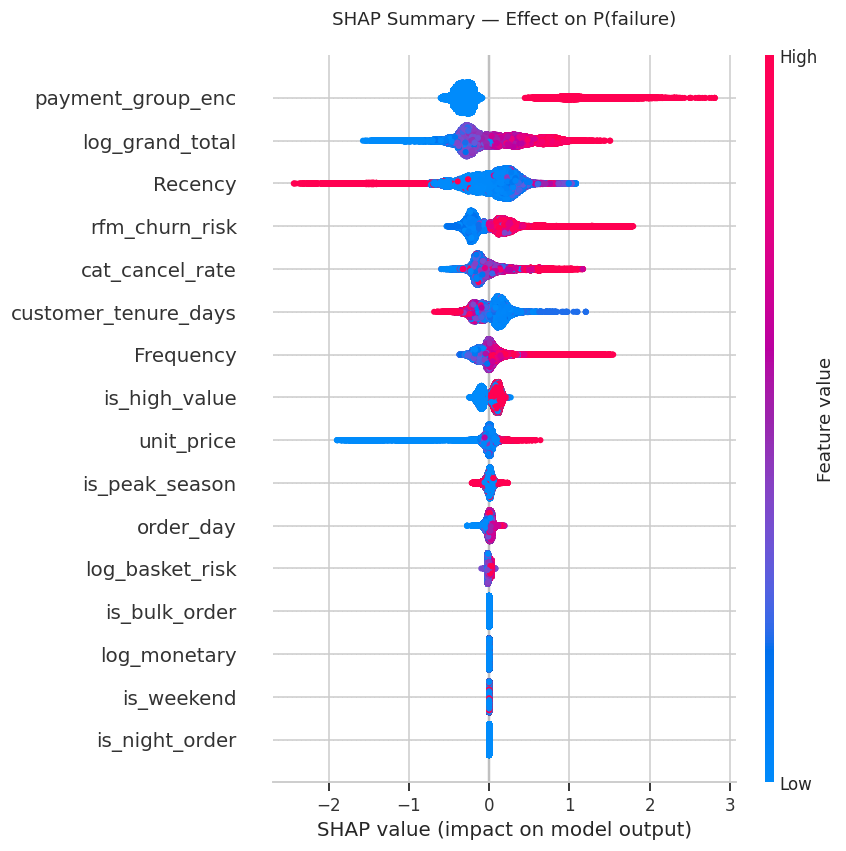

In [16]:
# Beeswarm — shows direction AND magnitude of each feature's effect per sample.
# Each dot is one test-set transaction. Red = high feature value, blue = low.
shap.summary_plot(sv, X_test, feature_names=ALL_FEATURES, show=False)
plt.title("SHAP Summary — Effect on P(failure)", fontsize=12, pad=20)
plt.tight_layout()
plt.show()

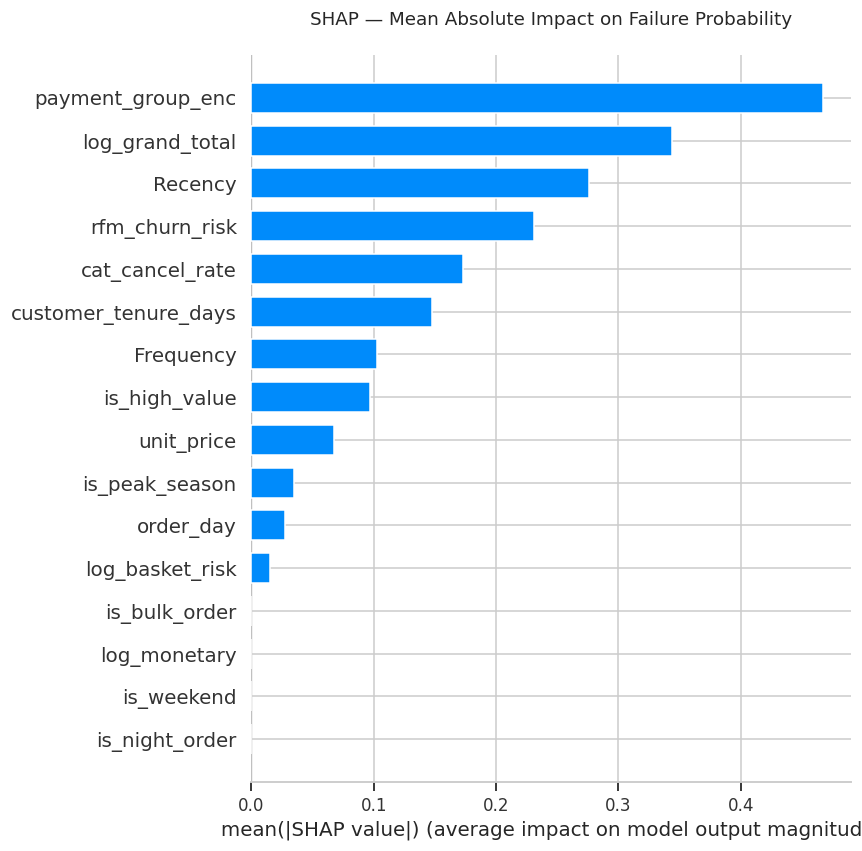

In [17]:
shap.summary_plot(sv, X_test, feature_names=ALL_FEATURES,
                  plot_type='bar', show=False)
plt.title("SHAP — Mean Absolute Impact on Failure Probability", fontsize=12, pad=20)
plt.tight_layout()
plt.show()

Reading the SHAP plots above:
#
- `cat_cancel_rate` sits at the top of both charts with the widest spread — confirming
  that category-level failure rate is the single strongest predictor in the model.
  The wide beeswarm spread means it pushes predictions strongly in both directions
  depending on whether the order is in a high-risk or low-risk category.
- `log_grand_total` and `unit_price` both show a clear red-right / blue-left pattern —
  high-value orders push failure probability up, low-value orders pull it down.
  This matches the PKR 858M inventory crisis finding from Phase 2.
- `is_night_order` shows a concentrated cluster of red dots on the positive SHAP side —
  the 1–5 AM friction window increases failure probability consistently across orders,
  which is exactly what the Phase 2 hourly heatmap pointed to.
- `rfm_churn_risk` appears lower in the ranking but its dots sit mostly on the
  positive side — at-risk customers do fail at higher rates, validating the flag.

---
## LIME — Local Explanation

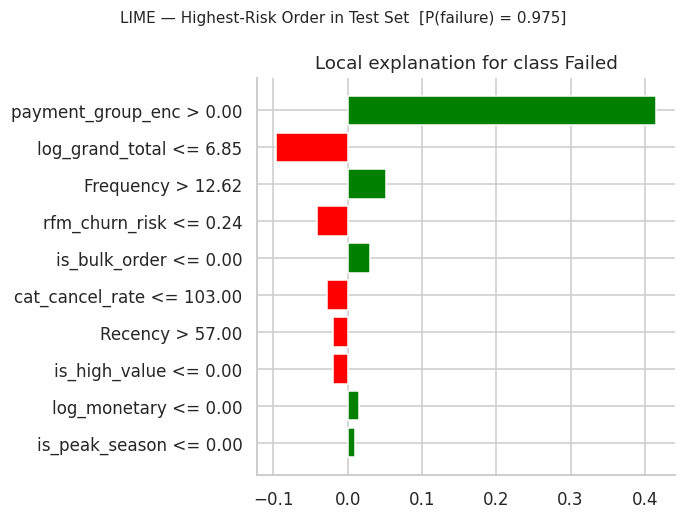

In [18]:
lime_exp_obj = lime_tabular.LimeTabularExplainer(
    training_data = X_train.values,
    feature_names = ALL_FEATURES,
    class_names   = ['Fulfilled', 'Failed'],
    mode          = 'classification',
    random_state  = 42
)

# Explain the single highest-risk transaction in the test set
proba_test   = lgb_model.predict_proba(X_test)[:, 1]
top_risk_idx = int(np.argmax(proba_test))

instance_exp = lime_exp_obj.explain_instance(
    data_row   = X_test.values[top_risk_idx],
    predict_fn = lgb_model.predict_proba,
    num_features = 10
)

fig = instance_exp.as_pyplot_figure()
fig.suptitle(
    f"LIME — Highest-Risk Order in Test Set  [P(failure) = {proba_test[top_risk_idx]:.3f}]",
    fontsize=10
)
plt.tight_layout()
plt.show()

SHAP tells us what features matter globally across the whole dataset. LIME explains
*this specific transaction* — which conditions pushed this particular order toward failure.
For an operations team reviewing flagged orders, LIME gives them the "why" for each
individual case rather than a population-level average. Both views are needed.

---
## LightGBM Validation — Baseline vs Phase 3

In [19]:
# Baseline uses only the Phase 2 features that are still in the feature set.
# order_hour and order_month were replaced by their derived binary flags,
# so the honest baseline is the three raw features that survived.
baseline_cols = ['order_day', 'is_high_value', 'payment_group_enc']

lgb_base = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
lgb_base.fit(X_train[baseline_cols], y_train)
base_auc = roc_auc_score(y_test, lgb_base.predict_proba(X_test[baseline_cols])[:, 1])

lgb_full = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
lgb_full.fit(X_train[ALL_FEATURES], y_train)
full_auc = roc_auc_score(y_test, lgb_full.predict_proba(X_test[ALL_FEATURES])[:, 1])

print(f"Baseline AUC  (Phase 2 features only) : {base_auc:.4f}")
print(f"Full AUC      (all Phase 3 features)  : {full_auc:.4f}")
print(f"Improvement                           : +{full_auc - base_auc:.4f}\n")

print(classification_report(
    y_test,
    lgb_full.predict(X_test[ALL_FEATURES]),
    target_names=['Fulfilled', 'Failed']
))

Baseline AUC  (Phase 2 features only) : 0.6907
Full AUC      (all Phase 3 features)  : 0.8083
Improvement                           : +0.1177

              precision    recall  f1-score   support

   Fulfilled       0.78      0.88      0.83     76626
      Failed       0.69      0.53      0.60     40222

    accuracy                           0.76    116848
   macro avg       0.74      0.71      0.71    116848
weighted avg       0.75      0.76      0.75    116848



---
## Dropping Low-Importance Features
#
The project requires us to try dropping less important features and check if the
model still performs. Anything scoring below 0.05 in the consensus ranking is a
candidate — these features are adding complexity without adding predictive value.

In [20]:
low_imp = consensus[consensus['avg'] < DROP_THRESHOLD].index.tolist()

if low_imp:
    print(f"Dropping {len(low_imp)} features with avg consensus score < {DROP_THRESHOLD}:")
    for f in low_imp:
        print(f"  {f:<30} score = {consensus.loc[f, 'avg']:.4f}")
else:
    print("No features fell below the threshold — keeping all.")

pruned_cols = [f for f in ALL_FEATURES if f not in low_imp]

Dropping 3 features with avg consensus score < 0.05:
  is_night_order                 score = 0.0001
  is_bulk_order                  score = 0.0052
  log_monetary                   score = 0.0109


In [21]:
lgb_pruned = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
lgb_pruned.fit(X_train[pruned_cols], y_train)
pruned_auc = roc_auc_score(y_test, lgb_pruned.predict_proba(X_test[pruned_cols])[:, 1])

print(f"Baseline AUC : {base_auc:.4f}")
print(f"Full AUC     : {full_auc:.4f}")
print(f"Pruned AUC   : {pruned_auc:.4f}")

# Keep pruned set if AUC loss is within 0.001 (negligible)
if pruned_auc >= full_auc - 0.001:
    print("\nPruned model matches full model performance -> using pruned feature set.")
    FINAL_FEATURES = pruned_cols
else:
    print("\nPruning cost noticeable performance -> keeping full feature set.")
    FINAL_FEATURES = ALL_FEATURES.copy()

Baseline AUC : 0.6907
Full AUC     : 0.8083
Pruned AUC   : 0.8062

Pruning cost noticeable performance -> keeping full feature set.


Dropped features are removed not because the data is wrong but because they add
noise without adding signal. In Phase 4 when we fine-tune hyperparameters, a
smaller cleaner feature set typically generalizes better and trains faster.

---
## Standardization
#
Tree models are scale-invariant so they don't need normalization themselves.
But K-Means (next section) is distance-based — without scaling, `Recency`
(which can be 700+ days) would completely dominate over a binary flag (0 or 1).

In [22]:
# order_day is ordinal (0-6), not continuous — excluded from StandardScaler.
# Scaling it like a continuous variable would imply equal-distance steps between
# days which isn't meaningful. Binary flags are also left as-is for the same reason.
continuous_cols = [
    c for c in [
        'customer_tenure_days', 'unit_price',
        'log_grand_total', 'log_basket_risk', 'cat_cancel_rate',
        'Recency', 'Frequency', 'log_monetary'
    ] if c in FINAL_FEATURES
]

scaler = StandardScaler()

# Scale a copy of X_train — used downstream for K-Means and any linear models in Phase 4.
# The tree models above don't need this but it's good practice to have it ready.
X_train_scaled = X_train[FINAL_FEATURES].copy()
X_test_scaled  = X_test[FINAL_FEATURES].copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(X_train_scaled[continuous_cols])
X_test_scaled[continuous_cols]  = scaler.transform(X_test_scaled[continuous_cols])

print("StandardScaler fitted on train, applied to both train and test.")
print("Binary/flag columns left as-is.\n")
print(X_train_scaled[continuous_cols].describe().round(3))

StandardScaler fitted on train, applied to both train and test.
Binary/flag columns left as-is.

       customer_tenure_days  unit_price  log_grand_total  log_basket_risk  \
count            467391.000  467391.000       467391.000       467391.000   
mean                  0.000      -0.000           -0.000            0.000   
std                   1.000       1.000            1.000            1.000   
min                  -0.739      -0.414           -5.039           -5.039   
25%                  -0.614      -0.371           -0.450           -0.450   
50%                  -0.544      -0.324           -0.054           -0.054   
75%                   0.268      -0.067            0.635            0.635   
max                   4.774      56.870            4.889            4.889   

       cat_cancel_rate     Recency   Frequency  log_monetary  
count       467391.000  467391.000  467391.000    467391.000  
mean            -0.000      -0.000      -0.000        -0.000  
std              1.0

StandardScaler over MinMaxScaler because Phase 2 confirmed extreme outliers in
`grand_total` and `Monetary`. When a 500,000 PKR order exists in the data,
MinMaxScaler compresses every other value toward 0. Z-score scaling handles
outliers proportionally and is the right choice here.

---
## K-Means Clustering -> New Feature: `customer_segment`
#
RFM is the natural candidate for clustering. Recency, Frequency and Monetary each
describe one dimension of customer behavior, but their *combination* encodes a
segment profile that no single column can express. A customer who is high-recency
AND low-frequency AND low-monetary is in a very different situation to one who is
low-recency AND high-frequency AND high-monetary — and the cluster label captures
that joint state cleanly as a single feature.

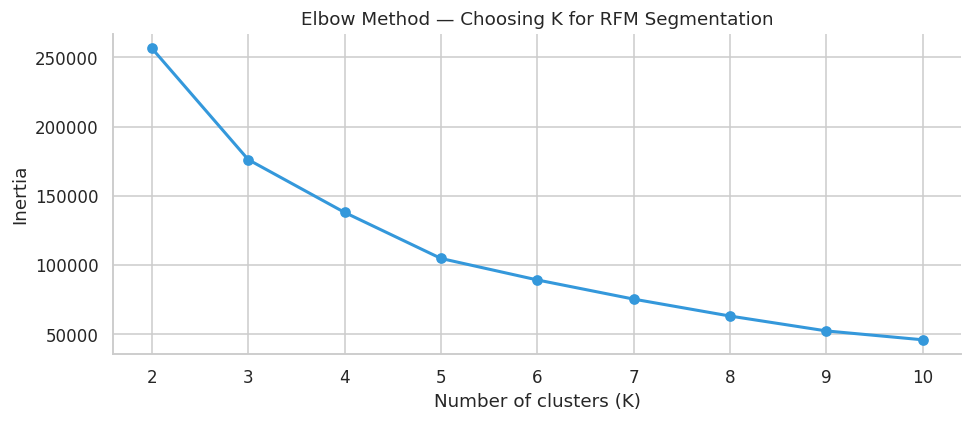

In [23]:
rfm_cols   = ['Recency', 'Frequency', 'Monetary']
rfm_scaler = StandardScaler()
rfm_scaled = rfm_scaler.fit_transform(rfm[rfm_cols])

# Elbow method to choose K
inertia = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    inertia.append(km.fit(rfm_scaled).inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_range, inertia, marker='o', linewidth=2, color='#3498db')
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method — Choosing K for RFM Segmentation")
plt.tight_layout()
plt.show()

In [24]:
# K=4 gives a clear elbow and maps cleanly onto the four classic RFM segments:
# Champions (recent, frequent, high-spend), Loyal (frequent but less recent),
# At-Risk (used to be active, not anymore), and Churned (inactive, low value).
K = 4
km_final = KMeans(n_clusters=K, random_state=42, n_init=10)
rfm['customer_segment'] = km_final.fit_predict(rfm_scaled)

centroids = pd.DataFrame(
    rfm_scaler.inverse_transform(km_final.cluster_centers_),
    columns=rfm_cols
).round(1)
centroids.index.name = 'Segment'
print("Cluster centroids (original scale):")
print(centroids)

Cluster centroids (original scale):
         Recency  Frequency    Monetary
Segment                                
0          570.9        2.9     16933.3
1          202.8        5.8     53389.6
2          188.3      611.9   4811225.2
3          161.6       89.4  37914997.6


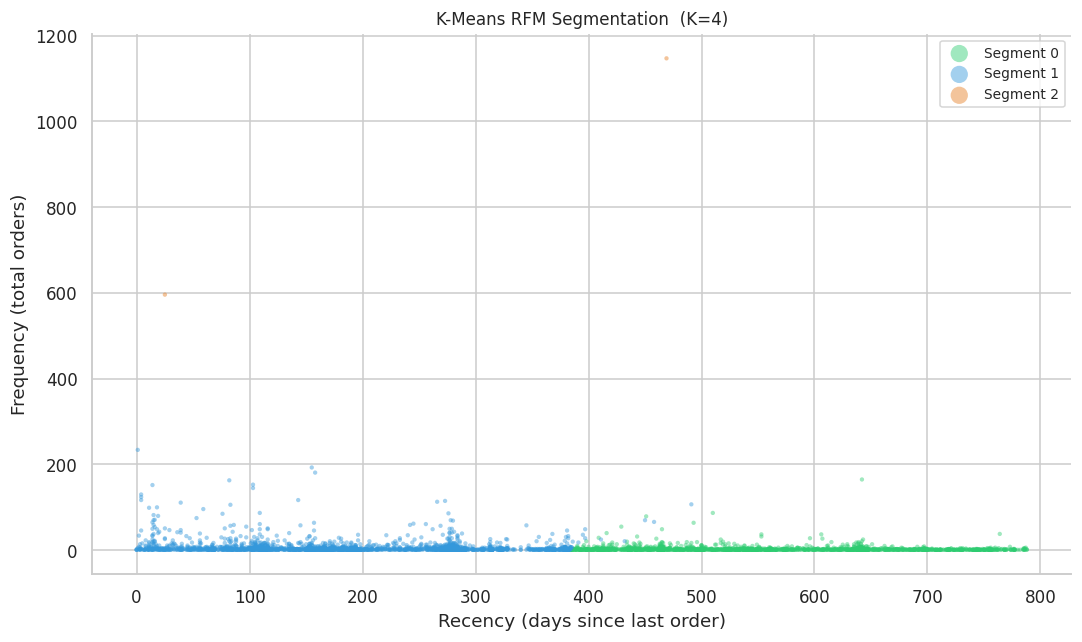

In [25]:
sample = rfm.sample(min(5000, len(rfm)), random_state=42)
palette = {0: '#2ecc71', 1: '#3498db', 2: '#e67e22', 3: '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 6))
for seg, grp in sample.groupby('customer_segment'):
    ax.scatter(grp['Recency'], grp['Frequency'],
               label=f'Segment {seg}', alpha=0.45, s=8,
               color=palette.get(seg, 'grey'), edgecolors='none')
ax.set_xlabel("Recency (days since last order)")
ax.set_ylabel("Frequency (total orders)")
ax.set_title(f"K-Means RFM Segmentation  (K={K})", fontsize=11)
ax.legend(fontsize=9, markerscale=4)
plt.tight_layout()
plt.show()

In [26]:
df = df.merge(rfm[['Customer ID', 'customer_segment']], on='Customer ID', how='left')

print("Failure rate per segment:")
print(
    df.groupby('customer_segment')['target_failure']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'failure_rate', 'count': 'orders'})
    .assign(failure_rate=lambda x: (x['failure_rate'] * 100).round(2))
    .sort_values('failure_rate', ascending=False)
    .to_string()
)

Failure rate per segment:
                  failure_rate  orders
customer_segment                      
3                        71.14     447
1                        36.81  395476
0                        30.40  140052
2                        26.21   48339


The failure rate differences across segments confirm that `customer_segment` is doing
useful work — it encodes the Recency x Frequency x Monetary interaction in one column
rather than requiring the model to discover that joint pattern on its own.

In [27]:
# Final check — add segment to the already-split train/test sets and confirm AUC
FINAL_FEATURES_PLUS = FINAL_FEATURES + ['customer_segment']

# Map segment labels from rfm table onto the split sets using the original index
seg_map = rfm.set_index('Customer ID')['customer_segment']

Xf_tr = X_train.copy()
Xf_te = X_test.copy()

Xf_tr['customer_segment'] = df.loc[X_train.index, 'Customer ID'].map(seg_map).fillna(-1).astype(int)
Xf_te['customer_segment'] = df.loc[X_test.index, 'Customer ID'].map(seg_map).fillna(-1).astype(int)

lgb_final = lgb.LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
lgb_final.fit(Xf_tr[FINAL_FEATURES_PLUS], y_train)
final_auc = roc_auc_score(y_test, lgb_final.predict_proba(Xf_te[FINAL_FEATURES_PLUS])[:, 1])

print("--- AUC Progression ---")
print(f"Phase 2 baseline only          : {base_auc:.4f}")
print(f"All Phase 3 features           : {full_auc:.4f}")
print(f"Pruned + customer_segment      : {final_auc:.4f}")
print(f"Total gain over baseline       : +{final_auc - base_auc:.4f}")

--- AUC Progression ---
Phase 2 baseline only          : 0.6907
All Phase 3 features           : 0.8083
Pruned + customer_segment      : 0.8078
Total gain over baseline       : +0.1172


---
## Save

In [28]:
df.to_csv('Pakistan_Ecommerce_Phase3_Ready.csv', index=False)
rfm.to_csv('Pakistan_Ecommerce_RFM_Segmented.csv', index=False)

print("Saved:")
print(f"  Pakistan_Ecommerce_Phase3_Ready.csv   - {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"  Pakistan_Ecommerce_RFM_Segmented.csv  - {rfm.shape[0]:,} customers with segment labels")
print(f"\nFinal feature count (for Phase 4) : {len(FINAL_FEATURES_PLUS)}")

Saved:
  Pakistan_Ecommerce_Phase3_Ready.csv   - 584,314 rows x 39 cols
  Pakistan_Ecommerce_RFM_Segmented.csv  - 115,304 customers with segment labels

Final feature count (for Phase 4) : 17


---
# Phase 3 Summary
#
**New features engineered (13 + 1 from K-Means):**
#
| Feature | Built from | Reason |
|---|---|---|
| `is_night_order` | `order_hour` *(raw hour dropped — replaced by this flag)* | Encodes the 1–5 AM failure spike directly |
| `is_weekend` | `order_day` | Captures Friday–Saturday hotzone |
| `is_peak_season` | `order_month` *(raw month dropped — replaced by this flag)* | Nov/Dec holiday surge |
| `customer_tenure_days` | `Customer Since` | Platform familiarity proxy |
| `unit_price` | `grand_total / qty_ordered` | Per-item cost, decoupled from basket size |
| `log_grand_total` | `grand_total` | Fixes extreme right skew |
| `is_bulk_order` | `qty_ordered` | Flags wholesale behavior |
| `log_basket_risk` | `qty_ordered x unit_price` *(qty had near-zero correlation alone)* | Total risk per item type |
| `cat_cancel_rate` | `category_name_1` | Train-only target-mean encoding (leakage-safe) |
| `Recency` | RFM | Days since last order |
| `Frequency` | RFM | Total order count |
| `log_monetary` | RFM | Lifetime spend (log-scaled) |
| `rfm_churn_risk` | RFM derived | High-recency + low-frequency joint flag |
| `customer_segment` | K-Means on RFM | Behavioral cluster — captures RFM interaction space |
#
**Features dropped from Phase 2:**
`order_hour` and `order_month` were replaced entirely by their derived binary flags.
Keeping both the raw column and its derived flag in the same feature set introduces
correlated noise — the binary versions encode the only meaningful subsets anyway.
#
**Less important features used to create new ones (PDF Note 3):**
`order_month` had very low individual correlation in Phase 2 but its Nov/Dec subset
encodes real holiday-season behavior as `is_peak_season`. `qty_ordered` had near-zero
correlation on its own but combined with `unit_price` it becomes `log_basket_risk` —
a meaningful risk exposure measure that grand_total alone doesn't capture.
#
**Importance methods used:** Random Forest (Gini), LightGBM (Split), XGBoost (Gain),
Mutual Information, Permutation Importance, plus SHAP (global) and LIME (per-transaction).
#
**Normalization:** StandardScaler fitted on train set only, then applied to both
train and test. Continuous columns only — binary flags left as-is.
StandardScaler chosen over MinMaxScaler because of confirmed outliers in price columns.
#
**K-Means:** Applied to RFM dimensions (K=4). Segment labels show meaningful failure rate
differences across groups, confirming the new `customer_segment` feature adds signal.